In [ ]:
# Célula 1: instalar bibliotecas
!pip install --quiet kaggle
!pip install --quiet scikit-learn pandas matplotlib seaborn nltk tqdm
!pip install --quiet scikit-surprise    #  experimentar CF (opcional)
!pip install --quiet sentence-transformers  #  experimentar modelos de embedding (opcional)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.4/154.4 kB 5.9 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving kaggle.json to kaggle.json


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle datasets download -d tmdb/tmdb-movie-metadata -p /content --unzip

Dataset URL: https://www.kaggle.com/datasets/tmdb/tmdb-movie-metadata
License(s): other
  0% 0.00/8.89M [00:00<?, ?B/s]
100% 8.89M/8.89M [00:00<00:00, 440MB/s]


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

movies = pd.read_csv('/content/tmdb_5000_movies.csv', low_memory=False)
credits = pd.read_csv('/content/tmdb_5000_credits.csv')

print("Movies:", movies.shape)
print("Credits:", credits.shape)
movies.head()


Movies: (4803, 20)
Credits: (4803, 4)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


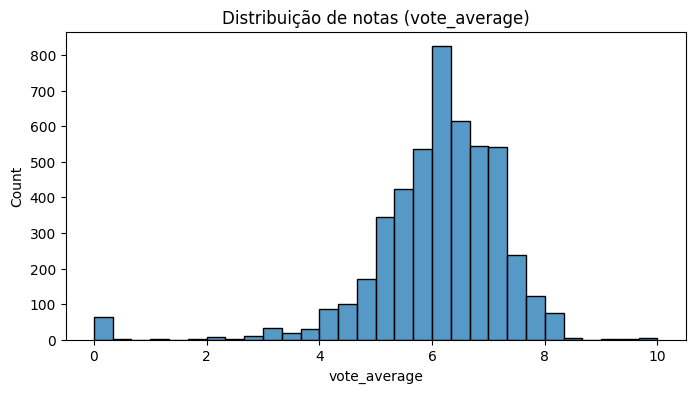

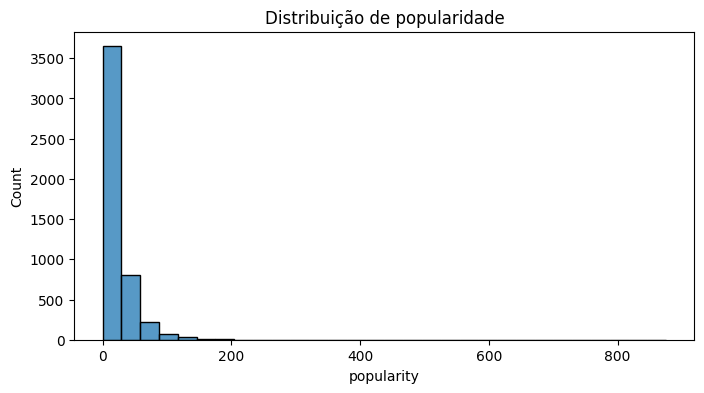

In [ ]:
# Célula 3b: EDA rápido
%matplotlib inline
plt.figure(figsize=(8,4))
sns.histplot(movies['vote_average'].dropna(), bins=30)
plt.title('Distribuição de notas (vote_average)')
plt.show()

plt.figure(figsize=(8,4))
sns.histplot(movies['popularity'].dropna(), bins=30)
plt.title('Distribuição de popularidade')
plt.show()


In [ ]:
# Ajustar id para merge
if 'movie_id' in credits.columns and 'id' in movies.columns:
    credits = credits.rename(columns={'movie_id':'id'})

# Merge (id é chave comum)
movies = movies.merge(credits[['id','cast']], on='id', how='left')


Funções de parsing (gêneros, diretor, atores)

In [ ]:
def parse_list_of_dicts(text, key='name'):
    if pd.isna(text):
        return []
    try:
        data = ast.literal_eval(text)
        return [d.get(key,'').lower().replace(" ", "") for d in data if key in d]
    except Exception:
        return []

def get_top_cast(cast_text, n=3):
    if pd.isna(cast_text):
        return []
    try:
        cast = ast.literal_eval(cast_text)
        names = [c.get('name','').lower().replace(" ", "") for c in cast[:n]]
        return names
    except:
        return []



Criar colunas de features

In [ ]:
movies['genres_parsed'] = movies['genres'].apply(lambda x: parse_list_of_dicts(x, 'name'))
movies['cast_parsed'] = movies['cast'].apply(lambda x: get_top_cast(x, n=3))

movies[['title','genres_parsed','cast_parsed']].head()


,title,genres_parsed,cast_parsed
0,Avatar,"[action, adventure, fantasy, sciencefiction]","[samworthington, zoesaldana, sigourneyweaver]"
1,Pirates of the Caribbean: At World's End,"[adventure, fantasy, action]","[johnnydepp, orlandobloom, keiraknightley]"
2,Spectre,"[action, adventure, crime]","[danielcraig, christophwaltz, léaseydoux]"
3,The Dark Knight Rises,"[action, crime, drama, thriller]","[christianbale, michaelcaine, garyoldman]"
4,John Carter,"[action, adventure, sciencefiction]","[taylorkitsch, lynncollins, samanthamorton]"


Criar soup (sem diretor e keywords)

In [ ]:
def list_to_str(l):
    return ' '.join(l) if isinstance(l, (list,tuple)) else ''

movies['overview'] = movies['overview'].fillna('').astype(str)
movies['soup'] = (
    movies['overview'] + ' ' +
    movies['genres_parsed'].apply(list_to_str) + ' ' +
    movies['cast_parsed'].apply(list_to_str)
)

movies[['title','soup']].head(3)


,title,soup
0,Avatar,"In the 22nd century, a paraplegic Marine is di..."
1,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha..."
2,Spectre,A cryptic message from Bond’s past sends him o...


Vetorização e Similaridade

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

count = CountVectorizer(stop_words='english', max_features=20000)
count_matrix = count.fit_transform(movies['soup'])
cosine_sim = cosine_similarity(count_matrix, count_matrix)

indices = pd.Series(movies.index, index=movies['title']).drop_duplicates()


Função de recomendação

In [ ]:
def get_recommendations(title, cosine_sim=cosine_sim, topn=10):
    if title not in indices:
        return f"Título '{title}' não encontrado no dataset."
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:topn+1]
    movie_indices = [i[0] for i in sim_scores]
    return movies[['title','vote_average','popularity']].iloc[movie_indices]

# Testar
print(get_recommendations("The Dark Knight Rises", topn=5))


                title  vote_average  popularity
65    The Dark Knight           8.2  187.322927
299    Batman Forever           5.2   48.205606
1359           Batman           7.0   44.104469
119     Batman Begins           7.5  115.040024
428    Batman Returns           6.6   59.113174


Avaliação do Modelo (Precision@K com gêneros)

In [ ]:
movies = movies.reset_index()
indices = pd.Series(movies.index, index=movies['title_x']).drop_duplicates()

print("Variável 'indices' definida.")
print("-" * 50)

# 2. Definição da função de recomendação (Depende de 'indices' e 'cosine_sim')
def get_recommendations(title, topn=5):
    """Retorna os títulos dos filmes mais similares."""
    try:
        idx = indices[title]

        sim_scores = list(enumerate(cosine_sim[idx]))
        sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
        sim_scores = sim_scores[1:topn + 1]
        movie_indices = [i[0] for i in sim_scores]

        # Retorna o título original, renomeado para 'title'
        return movies.iloc[movie_indices][['title_x']].rename(columns={'title_x': 'title'})

    except KeyError:
        return f"Erro: Filme '{title}' não encontrado no índice."
    except Exception as e:
        return f"Erro inesperado: {e}"

Variável 'indices' definida.
--------------------------------------------------


In [ ]:
# ----------------------------------------------------------------------
# 4. FUNÇÃO E ROTINA DE VALIDAÇÃO (Precision@K) - CORRIGIDA
# ----------------------------------------------------------------------

def precision_at_k(title, k=5):
    """
    Calcula a Precision@K. Um filme recomendado é relevante se compartilha
    ao menos um gênero com o filme de consulta.

    Dependências: 'indices', 'movies['genres_parsed']', 'get_recommendations'
    """

    # 1. Checa se o filme de consulta existe no índice
    if title not in indices.index:
        return None

    idx = indices[title]
    # Se o índice do filme de consulta for uma Series (duplicata), pegue apenas o primeiro
    if isinstance(idx, pd.Series):
        idx = idx.iloc[0]

    target_genres = set(movies.loc[idx, 'genres_parsed'])

    if not target_genres:
        return None

    # 2. Obtém as recomendações
    recs = get_recommendations(title, topn=k)

    if not isinstance(recs, pd.DataFrame):
        return None

    relevant = 0
    total_recomendacoes = 0

    # 3. Avalia cada recomendação
    for rec_title in recs['title']:
        if rec_title not in indices.index:
            continue
        rec_idx_value = indices[rec_title]

        # Se o resultado da busca for uma Series (título duplicado), pegue o primeiro valor
        if isinstance(rec_idx_value, pd.Series):
            rec_idx = rec_idx_value.iloc[0]
        else:
            rec_idx = rec_idx_value
        rec_genres = set(movies.loc[rec_idx, 'genres_parsed'])

        # Condição de Relevância
        if rec_genres.intersection(target_genres):
            relevant += 1
        total_recomendacoes += 1

    if total_recomendacoes == 0:
        return 0.0

    return relevant / total_recomendacoes

titulos_teste = [
    "Avatar",
    "The Dark Knight Rises",
    "Spectre",
    "John Carter",
    "Pulp Fiction",
    "Inception",
    "Fight Club",
    "The Green Mile",
    "Deadpool",
    "The Avengers"
]

lista_precisions = []
print("\nIniciando cálculo da Precision@5 para os filmes de teste...")
for title in titulos_teste:
    prec = precision_at_k(title, k=5)

    if prec is not None:
        lista_precisions.append(prec)
    else:
        print(f"Aviso: Pulando '{title}' (não encontrado no índice de filmes ou erro de dados).")

# Cálculos finais
if lista_precisions:
    media_precision = np.mean(lista_precisions)
    desvio_padrao = np.std(lista_precisions)

    print("\n--- Resultados de Desempenho (Precision@5) ---")
    print(f"Número de filmes testados: {len(lista_precisions)}")
    print(f"Média da Precision@5: {media_precision:.4f}")
    print(f"Dispersão (Desvio Padrão): {desvio_padrao:.4f}")
else:
    print("\nERRO CRÍTICO: Nenhuma precisão pôde ser calculada. Verifique se as variáveis de setup estão definidas e se a lista de testes é válida.")


Iniciando cálculo da Precision@5 para os filmes de teste...

--- Resultados de Desempenho (Precision@5) ---
Número de filmes testados: 10
Média da Precision@5: 0.8200
Dispersão (Desvio Padrão): 0.3027


1. Quantos filmes existem no dataset?

In [ ]:
print("Quantidade de filmes no dataset:", movies['id'].nunique())

Quantidade de filmes no dataset: 4803


2. Quais são os gêneros mais frequentes?

/tmp/ipython-input-2908592440.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=all_genres.values, y=all_genres.index, palette="viridis")


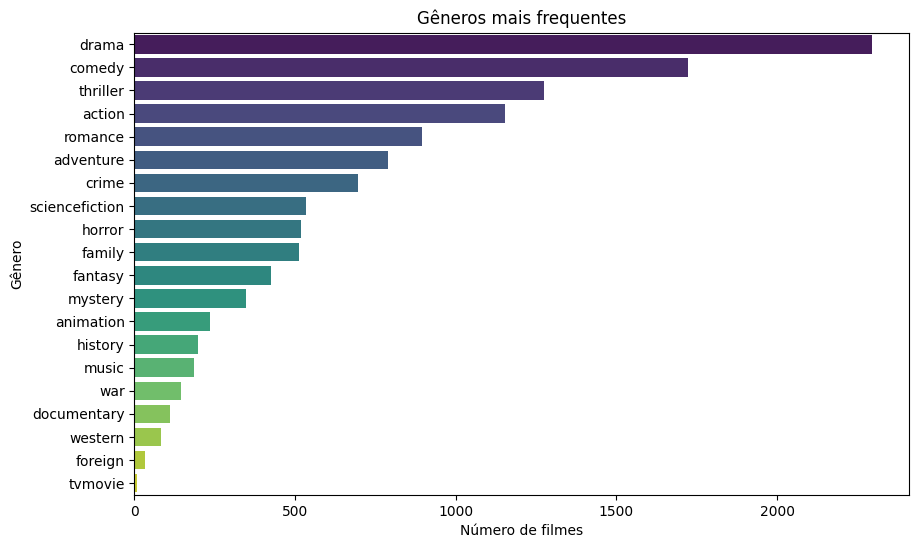

In [ ]:
# "Explodir" a lista de gêneros em linhas separadas
all_genres = movies['genres_parsed'].explode().value_counts()

plt.figure(figsize=(10,6))
sns.barplot(x=all_genres.values, y=all_genres.index, palette="viridis")
plt.title("Gêneros mais frequentes")
plt.xlabel("Número de filmes")
plt.ylabel("Gênero")
plt.show()


3. Distribuição das notas de avaliação (vote_average)

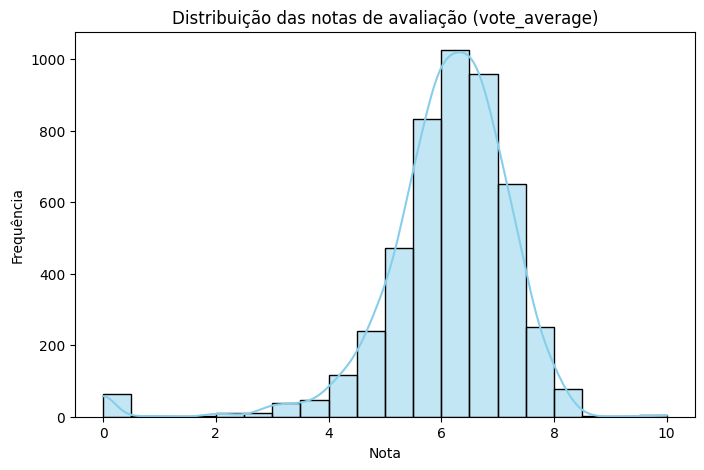

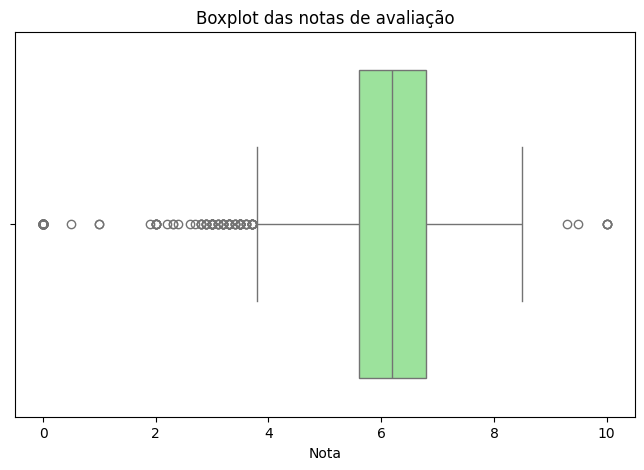

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(movies['vote_average'], bins=20, kde=True, color="skyblue")
plt.title("Distribuição das notas de avaliação (vote_average)")
plt.xlabel("Nota")
plt.ylabel("Frequência")
plt.show()

plt.figure(figsize=(8,5))
sns.boxplot(x=movies['vote_average'], color="lightgreen")
plt.title("Boxplot das notas de avaliação")
plt.xlabel("Nota")
plt.show()


4. Filmes mais populares e mais votados

/tmp/ipython-input-25844346.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='popularity', y='title', data=top_pop, palette="mako")


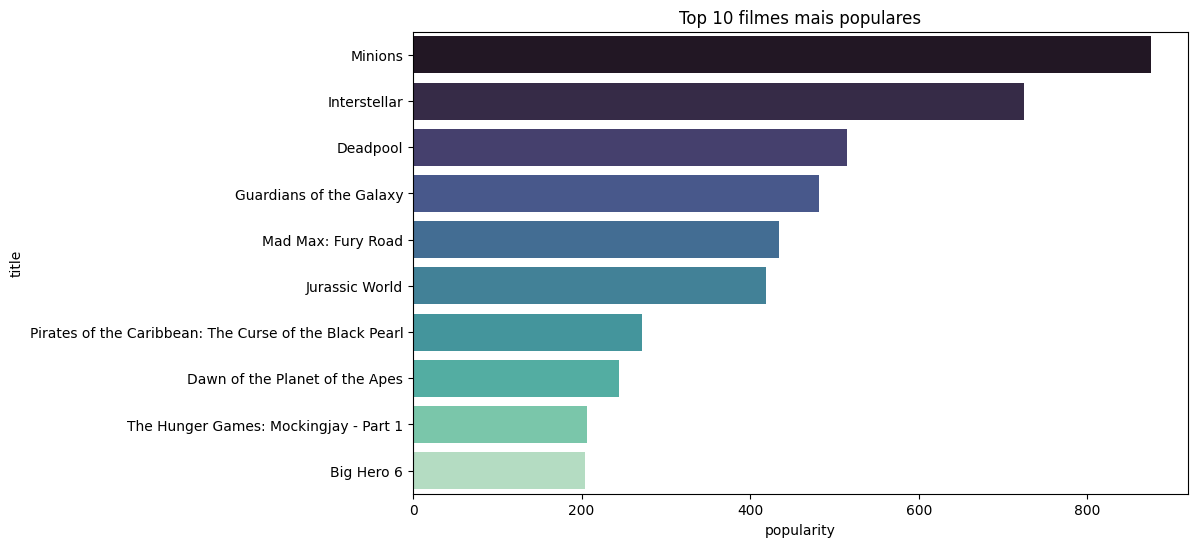

/tmp/ipython-input-25844346.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='vote_count', y='title', data=top_votes, palette="rocket")


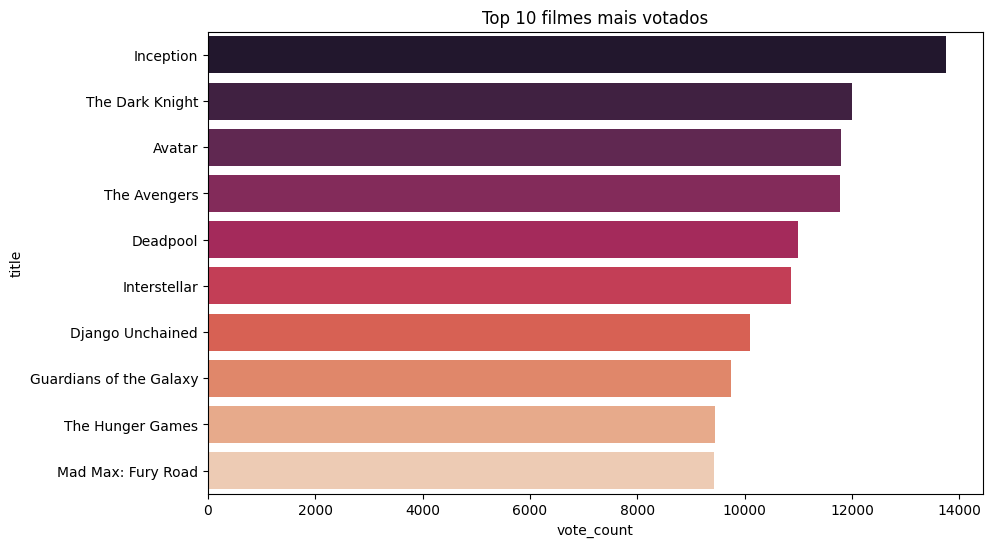

In [ ]:
# Top 10 mais populares
top_pop = movies[['title','popularity']].sort_values(by='popularity', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='popularity', y='title', data=top_pop, palette="mako")
plt.title("Top 10 filmes mais populares")
plt.show()

# Top 10 mais votados
top_votes = movies[['title','vote_count']].sort_values(by='vote_count', ascending=False).head(10)

plt.figure(figsize=(10,6))
sns.barplot(x='vote_count', y='title', data=top_votes, palette="rocket")
plt.title("Top 10 filmes mais votados")
plt.show()


5. Relação entre orçamento, receita e popularidade

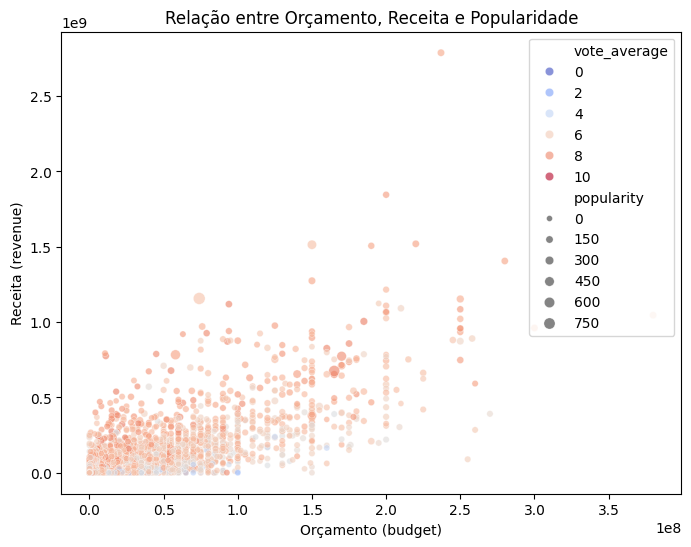

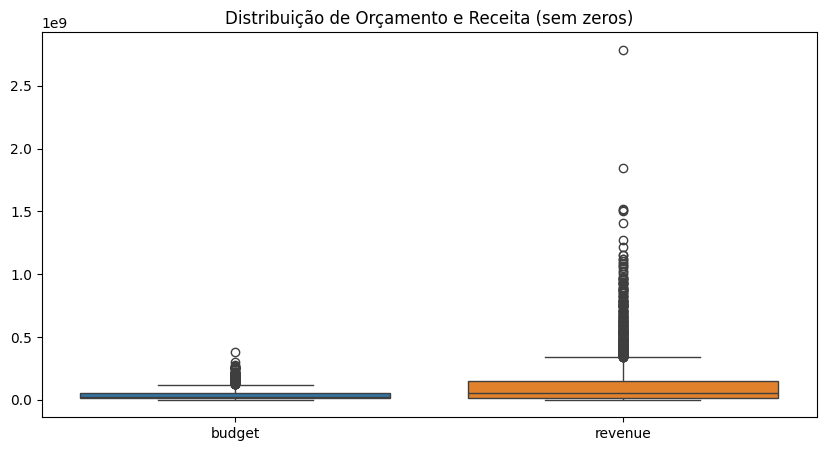

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=movies, x="budget", y="revenue", size="popularity", hue="vote_average", alpha=0.6, palette="coolwarm")
plt.title("Relação entre Orçamento, Receita e Popularidade")
plt.xlabel("Orçamento (budget)")
plt.ylabel("Receita (revenue)")
plt.legend()
plt.show()

# Boxplot do orçamento e receita (removendo outliers extremos)
filtered = movies[(movies['budget']>0) & (movies['revenue']>0)]

plt.figure(figsize=(10,5))
sns.boxplot(data=filtered[['budget','revenue']])
plt.title("Distribuição de Orçamento e Receita (sem zeros)")
plt.show()
